# 선형회귀(Numpy)

> 선형 회귀는 독립변수(x)와 종속변수(y)간의 선형 관계를 모델링해서 "예측"하는 통계 기법입니다.

# 모델
- 단순 모델: y = ax + b
- 다중 모델: y = a1x1 + a2x2 + ... + anxn + b

# 머신러닝 활용
- y와 x가 결정 -> {a,b} 매개변수를 찾아야 함
- y와 x가 선형 관계를 가져야 함, 이상치와 다중공선성

# {a,b} 매개변수를 찾아야 함!
- 매개변수를 찾는 방법 : 최소제곱법(기울기를구하는방법), 경사하강법
- 평가 : MSE, R^2


예제1. 어떤 회사의 연도별 매출이 광고비에 의존한다고 가정.
아래 데이터가 주어질 때, 광고비가 8일때 매출을 예상하시오.

|광고비(x독립) |매출(y종속) |
|------|----|
|2 | 81 |
|4 | 93|
|6 | 91|
|8 | ? |

- y = ax + b
- 81 = 2a + b
- 93 = 4a + b
- 91 = 6a + b
- ? = 8a + b

In [6]:
import numpy as np

# 데이터 준비
x = np.array([2,4,6])
y = np.array([81,93,91])

# 최소제곱법 -> 평균구하기
x_mean = np.mean(x)
y_mean = np.mean(y)

# 최소제곱법 -> 계산하기
# Cov(x,y) / Var(x) => a를구하는방법
# 제곱의합(ss)이 최소가 되는해
# 최소제곱법의 기울기
# a = np.sum((x - x_mean) * (y- y_mean)) / np.sum((x-x_mean) **2)
# b = y_mean - a * x_mean

# numpy 최소제곱법
# 임의의 b값을 넣어줘야함
x = np.column_stack([x, np.ones(len(x))])
a,b = np.linalg.lstsq(x,y)[0]

print(f"기울기: {a:.2f}, 절편: {b:.2f}")

x_pred = 8
y_pred = 8
print(f"광고비(8) 예측 매출: {y_pred:.2f}")

기울기: 2.50, 절편: 78.33
광고비(8) 예측 매출: 8.00



예제2. 어떤 회사에서 만드는 물건의 판매량이 가격과 온도에 영향을 받는다고 가정.
가격이 8이고 온도가 24일때 판매량을 예측하세요

|가격(x1) |온도(x2) |판매량(y)
|------|----|------|
|5 | 20 |65|
|7 | 22|70|
|9 | 23|60|
|8 | 24 |?|

- y = a1x1 + a2x2 + b

In [9]:
import numpy as np
# 데이터 준비
x = np.array([[5,20],[7,22],[9,23]])
y = np.array([65,70,60])

# 컬럼추가
x_bias = np.column_stack([x, np.ones(len(x))])

# 최소제곱법(계산) => a1,a2(독립1,2), y(종속)
# a1,a2,b = np.linalg.lstsq(x_bias,y)[0]
coeffs = np.linalg.lstsq(x_bias,y)[0]

# print(f"기울기: {a:.2f}, 절편: {b:.2f}")
print(f"기울기1: {coeffs[0]:.2f},기울기2: {coeffs[1]:.2f}, 절편: {coeffs[-1]:.2f}")

print(coeffs.shape)

# np.dot => * /@
y_pred = x_pred = np.dot([8,24,1],coeffs)
print(f"{y_pred:.2f}")



기울기1: -12.50,기울기2: 15.00, 절편: -172.50
(3,)
87.50


## numpy를 활용한 선형회귀 모델(v1)
> scikit-learn

In [10]:
!pip install scikit-learn

<!-- 회기분석을 위해 데이터준비 시작 -->


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [ ]:
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# y
iris_df["target"] = iris.target
# iris_df.head()

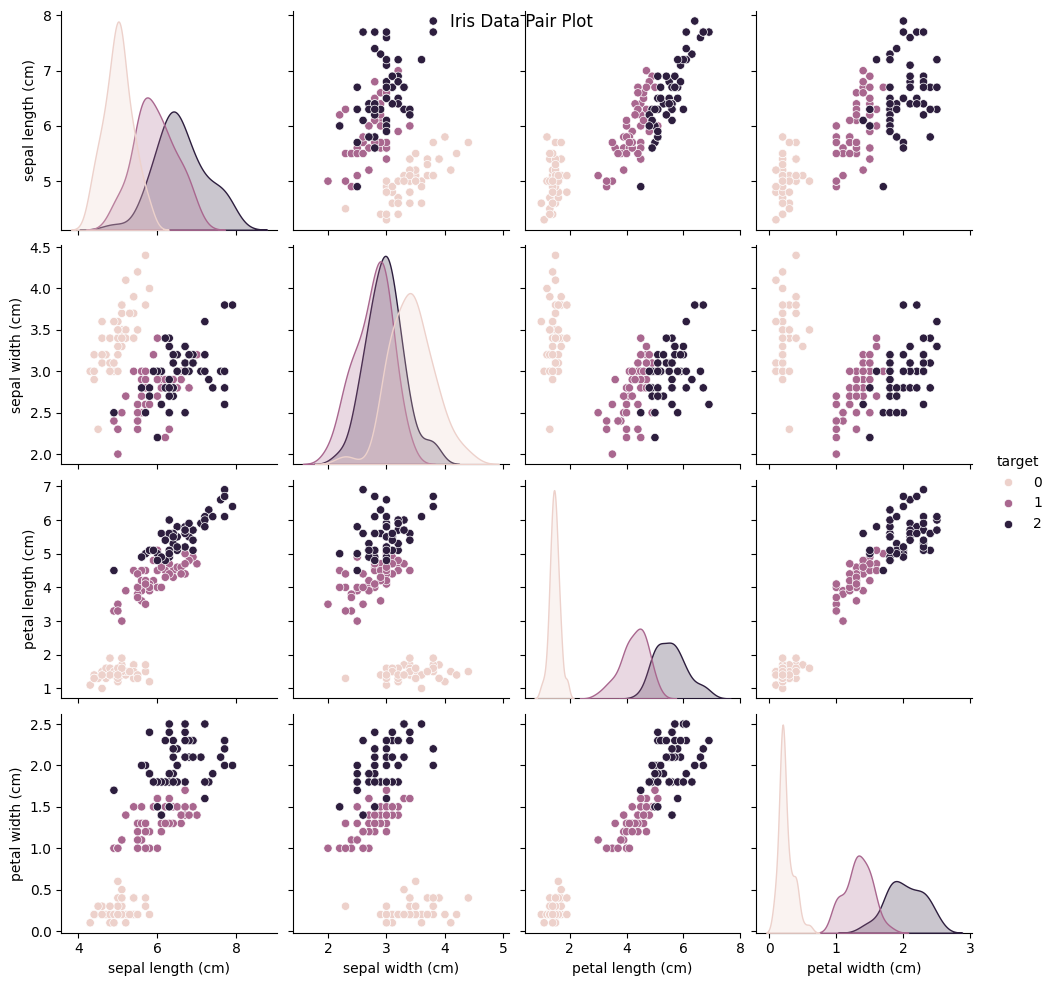

In [ ]:
sns.pairplot(iris_df, hue="target")
# y = target
plt.suptitle("Iris Data Pair Plot")
plt.show()

<!-- ~~ 회기분석을 위해 데이터준비 끝 -->

회귀모델 => 실수 또는 연속된 정수 => 범주에 사용하지않기 때문
1. 전치리
    y, x 결정
2. 모델
3. 예측
4. 평가

In [ ]:
# 1. y, x 결정 (y= sepal width (cm))
iris_df.info()
iris.feature_names
       #np.column_stack 여러데이터 합칠수있음
x = np.column_stack([iris.data[:,0], iris.data[:,2], iris.data[:,3]])
y = iris.data[:, 1]
print(x.shape, y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
(150, 3) (150,)


In [25]:
# 데이터 분할 함수 (모델/예측)
def custom_train_test_split(x,y, test_size = 0.3, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(x))
    # 상하한구하기
    split_idx = int(len(x)* (1-test_size))
    train_idx = indices[:split_idx]
    test_idx = indices[split_idx:]
    # 데이터셋분할
    x_train = x[train_idx]
    x_test = x[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    return x_train, x_test,  y_train, y_test

In [26]:
x_train, x_test,  y_train, y_test = custom_train_test_split(x,y)
print(x_train.shape, x_test.shape,  y_train.shape, y_test.shape)

(105, 3) (45, 3) (105,) (45,)


In [39]:
# 최소제곱법
def fit_linear_regreesion_lsq(x,y):
    # 절편(매개변수 순서 조심)
    x_bias = np.column_stack([np.ones(len(x)),x])
    cofficients, _, _,_ = np.linalg.lstsq(x_bias,y)

    intercept_ = cofficients[0]
    coef_ =cofficients[1:]
    return coef_, intercept_

In [ ]:
# x_bias = np.column_stack([x,np.ones(len(x))])
# cofficients, residuals, rank,s = np.linalg.lstsq(x_bias,y)

In [40]:
# 예측
def predict_linear_regreesion_lsq(x,coef_, intercept_):
    return x @ coef_ + intercept_

In [42]:
coef_, intercept_ = fit_linear_regreesion_lsq(x_train, y_train)
y_pred_custom = predict_linear_regreesion_lsq(x_test, coef_, intercept_)

In [43]:
# 평가
mse_custom = mean_squared_error(y_test, y_pred_custom)
r2_custom = r2_score(y_test, y_pred_custom)
print(mse_custom, r2_custom)

0.08472197157942186 0.38100017156758104


In [44]:
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
mse_custom = mean_squared_error(y_test, y_pred_lr)
r2_custom = r2_score(y_test, y_pred_lr)
print(mse_custom, r2_custom)

0.08472197157942134 0.3810001715675848


## 시각화

In [53]:
from sklearn.linear_model import BayesianRidge
br = BayesianRidge()
br.fit(x_train, y_train)
y_pred_br = br.predict(x_test)
mse_Br = mean_squared_error(y_test, y_pred_br)
r2_br = r2_score(y_test, y_pred_br)

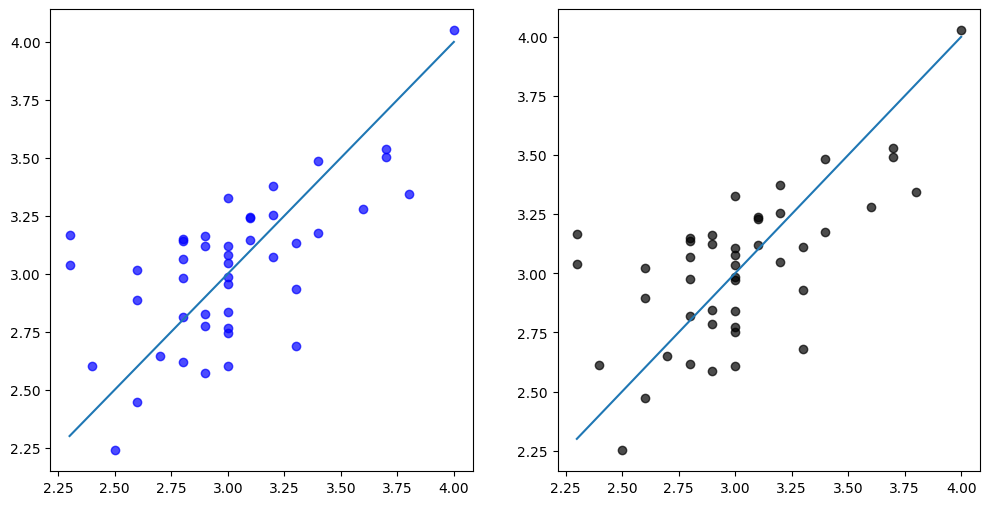

In [54]:
fig, axes = plt.subplots(1,2, figsize=(12,6))

axes[0].scatter(y_test, y_pred_custom, alpha=0.7, color="blue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()]);
# axes[0].set_xlabel("")
# axes[0].set_ylabel("")
axes[1].scatter(y_test, y_pred_br, alpha=0.7, color="black")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()]);
# axes[1].set_xlabel("")
# axes[1].set_ylabel("")